In [ ]:
# Install libraries (run once if needed)
# !pip install numpy opencv-python scikit-image pywavelets matplotlib

import numpy as np
import cv2
import pywt
import matplotlib.pyplot as plt
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim

# TEXT → BITS
def text_to_bits(text):
    bits=[]
    for c in text.encode():
        for i in range(8):
            bits.append((c>>i)&1)
    return bits

# BITS → TEXT
def bits_to_text(bits):
    chars=[]
    for i in range(0,len(bits),8):
        val=0
        for j in range(8):
            val |= bits[i+j] << j
        chars.append(val)
    return bytes(chars).decode(errors="ignore")

# EMBED BITS
def embed_bits(coeff,bits):
    coeff=coeff.copy()
    flat=coeff.flatten()
    for i in range(len(bits)):
        if bits[i]==1:
            flat[i]|=2
        else:
            flat[i]&=~2
    return flat.reshape(coeff.shape)

# EXTRACT BITS
def extract_bits(coeff,length):
    flat=coeff.flatten()
    bits=[]
    for i in range(length):
        bits.append((flat[i]>>1)&1)
    return bits

# EMBEDDING FUNCTION
def embed_secret(image,message):

    gray=cv2.cvtColor(image,cv2.COLOR_BGR2GRAY)

    secret_bits=text_to_bits(message)

    length=len(secret_bits)

    length_bits=[(length>>i)&1 for i in range(32)]

    payload=length_bits+secret_bits

    LL,(LH,HL,HH)=pywt.dwt2(gray,'haar')

    LH=np.round(LH*10).astype(np.int32)

    LH=embed_bits(LH,payload)

    LH=LH.astype(np.float32)/10

    stego=pywt.idwt2((LL,(LH,HL,HH)),'haar')

    stego=np.clip(stego,0,255).astype(np.uint8)

    return stego

# EXTRACTION FUNCTION
def extract_secret(stego):

    LL,(LH,HL,HH)=pywt.dwt2(stego,'haar')

    LH=np.round(LH*10).astype(np.int32)

    extracted_bits=extract_bits(LH,10000)

    length=0
    for i in range(32):
        length |= extracted_bits[i] << i

    message_bits=extracted_bits[32:32+length]

    return bits_to_text(message_bits)
def ber(a,b):

    errors=sum(i!=j for i,j in zip(a,b))

    return errors/len(a)

In [ ]:
image=cv2.imread("image.jpg")

secret="HELLO WORLD"

# EMBED MESSAGE
stego=embed_secret(image,secret)

# EXTRACT MESSAGE
extracted=extract_secret(stego)

print("Extracted:",extracted)

original_gray=cv2.cvtColor(image,cv2.COLOR_BGR2GRAY)

print("PSNR:",psnr(original_gray,stego))
print("SSIM:",ssim(original_gray,stego))
print("BER:", ber(secret,extracted))


Extracted: HELLO WORLD
PSNR: 74.22380164249111
SSIM: 0.9999932454656473
BER: 0.0


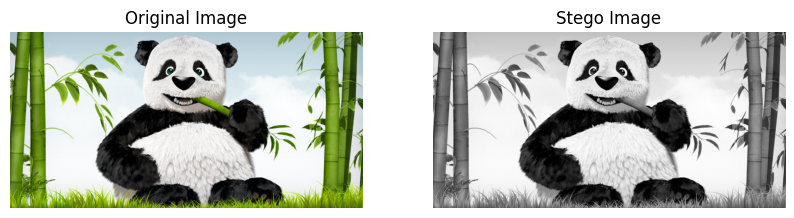

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.title("Original Image")
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.axis("off")

plt.subplot(1,2,2)
plt.title("Stego Image")
plt.imshow(stego, cmap="gray")
plt.axis("off")

plt.show()